<a href="https://colab.research.google.com/github/abdulrasheedmd2005/Week2-DataScience-Tasks/blob/main/Student_Dropout_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

Educational institutions face challenges in identifying students who are likely to dropout.

The goal of this project is to analyze student engagement and academic performance data to predict dropout likelihood using machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student_dropout.csv to student_dropout.csv


# Approach

The project followed these steps:

1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Building
6. Model Evaluation
7. Business Insights

In [ ]:
df = pd.read_csv('student_dropout.csv')

# Dataset Description

The dataset contains:

- Student demographics
- Quiz scores
- Assignment completion rate
- Forum participation
- Learning behavior
- Engagement level
- Final exam scores

In [ ]:
df.head()

,Student_ID,Age,Gender,Education_Level,Course_Name,Time_Spent_on_Videos,Quiz_Attempts,Quiz_Scores,Forum_Participation,Assignment_Completion_Rate,Engagement_Level,Final_Exam_Score,Learning_Style,Feedback_Score,Dropout_Likelihood
0,S00001,15,Female,High School,Machine Learning,171,4,67,2,89,Medium,51,Visual,1,No
1,S00002,49,Male,Undergraduate,Python Basics,156,4,64,0,94,Medium,92,Reading/Writing,5,No
2,S00003,20,Female,Undergraduate,Python Basics,217,2,55,2,67,Medium,45,Reading/Writing,1,No
3,S00004,37,Female,Undergraduate,Data Science,489,1,65,43,60,High,59,Visual,4,No
4,S00005,34,Female,Postgraduate,Python Basics,496,3,59,34,88,Medium,93,Visual,3,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Student_ID                  10000 non-null  object
 1   Age                         10000 non-null  int64 
 2   Gender                      10000 non-null  object
 3   Education_Level             10000 non-null  object
 4   Course_Name                 10000 non-null  object
 5   Time_Spent_on_Videos        10000 non-null  int64 
 6   Quiz_Attempts               10000 non-null  int64 
 7   Quiz_Scores                 10000 non-null  int64 
 8   Forum_Participation         10000 non-null  int64 
 9   Assignment_Completion_Rate  10000 non-null  int64 
 10  Engagement_Level            10000 non-null  object
 11  Final_Exam_Score            10000 non-null  int64 
 12  Learning_Style              10000 non-null  object
 13  Feedback_Score              10000 non-null  int

In [ ]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Education_Level,0
Course_Name,0
Time_Spent_on_Videos,0
Quiz_Attempts,0
Quiz_Scores,0
Forum_Participation,0
Assignment_Completion_Rate,0


In [ ]:
df=df.dropna()

In [ ]:
encoder = LabelEncoder()

In [ ]:
df['Learning_Style'] = encoder.fit_transform(df['Learning_Style'])

In [ ]:
df['Engagement_Level'] = encoder.fit_transform(df['Engagement_Level'])

In [ ]:
df['Dropout_Likelihood'] = encoder.fit_transform(df['Dropout_Likelihood'])

In [ ]:
df['Gender'] = encoder.fit_transform(df['Gender'])

In [ ]:
df['Education_Level'] = encoder.fit_transform(df['Education_Level'])

In [ ]:
df['Course_Name'] = encoder.fit_transform(df['Course_Name'])

In [ ]:
df.describe()

,Age,Gender,Education_Level,Course_Name,Time_Spent_on_Videos,Quiz_Attempts,Quiz_Scores,Forum_Participation,Assignment_Completion_Rate,Engagement_Level,Final_Exam_Score,Learning_Style,Feedback_Score,Dropout_Likelihood
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,32.137700,0.55290,1.214700,1.986400,255.375400,2.500500,64.578600,24.616200,69.546800,1.194700,64.697000,1.512600,3.012600,0.195700
std,10.062647,0.57466,0.867917,1.410466,141.656392,1.122642,20.289125,14.330305,17.360782,0.867679,20.096417,1.118287,1.421423,0.396758
min,15.000000,0.00000,0.000000,0.000000,10.000000,1.000000,30.000000,0.000000,40.000000,0.000000,30.000000,0.000000,1.000000,0.000000
25%,24.000000,0.00000,0.000000,1.000000,131.000000,1.000000,47.000000,12.000000,54.000000,0.000000,47.000000,1.000000,2.000000,0.000000
50%,32.000000,1.00000,2.000000,2.000000,257.000000,3.000000,65.000000,25.000000,69.000000,1.000000,65.000000,2.000000,3.000000,0.000000
75%,41.000000,1.00000,2.000000,3.000000,378.000000,4.000000,82.000000,37.000000,85.000000,2.000000,82.000000,3.000000,4.000000,0.000000
max,49.000000,2.00000,2.000000,4.000000,499.000000,4.000000,99.000000,49.000000,99.000000,2.000000,99.000000,3.000000,5.000000,1.000000


# Exploratory Data Analysis

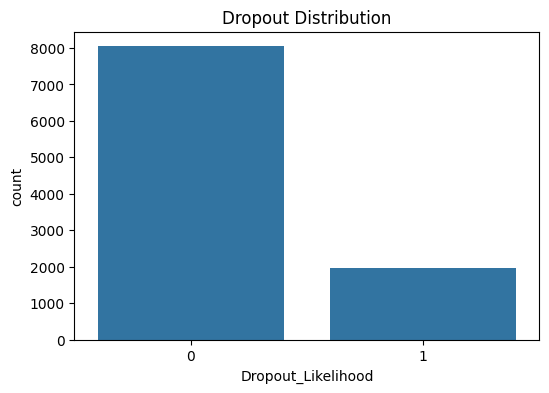

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Dropout_Likelihood', data=df)
plt.title('Dropout Distribution')
plt.show()

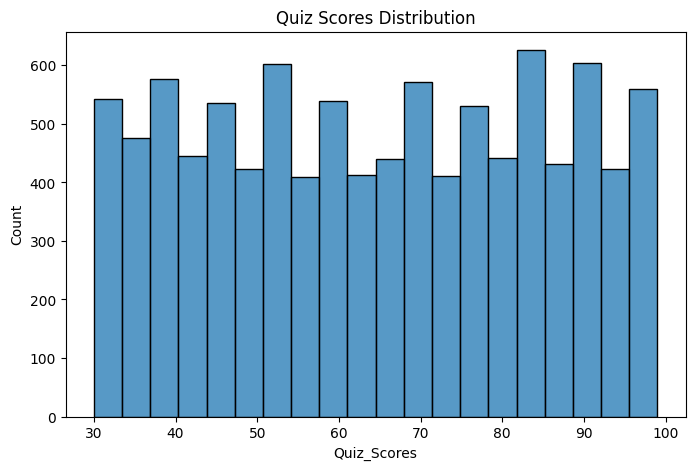

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Quiz_Scores'],bins=20)
plt.title('Quiz Scores Distribution')
plt.show()

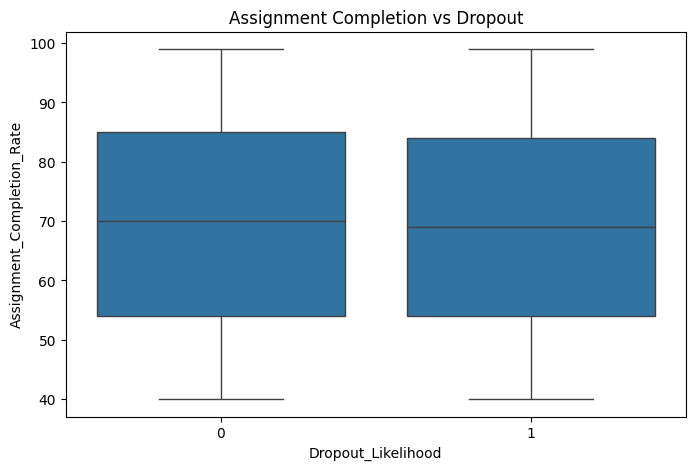

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Dropout_Likelihood',y='Assignment_Completion_Rate',data=df)
plt.title('Assignment Completion vs Dropout')
plt.show()

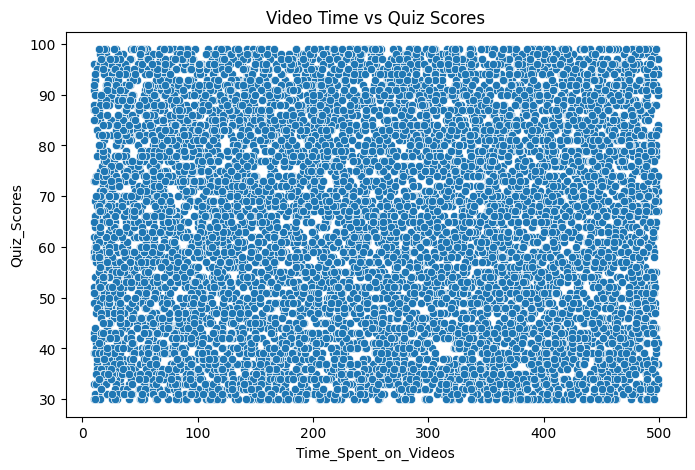

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Time_Spent_on_Videos',y='Quiz_Scores',data=df)
plt.title('Video Time vs Quiz Scores')
plt.show()

In [ ]:
df=df.drop(['Student_ID'],axis=1)

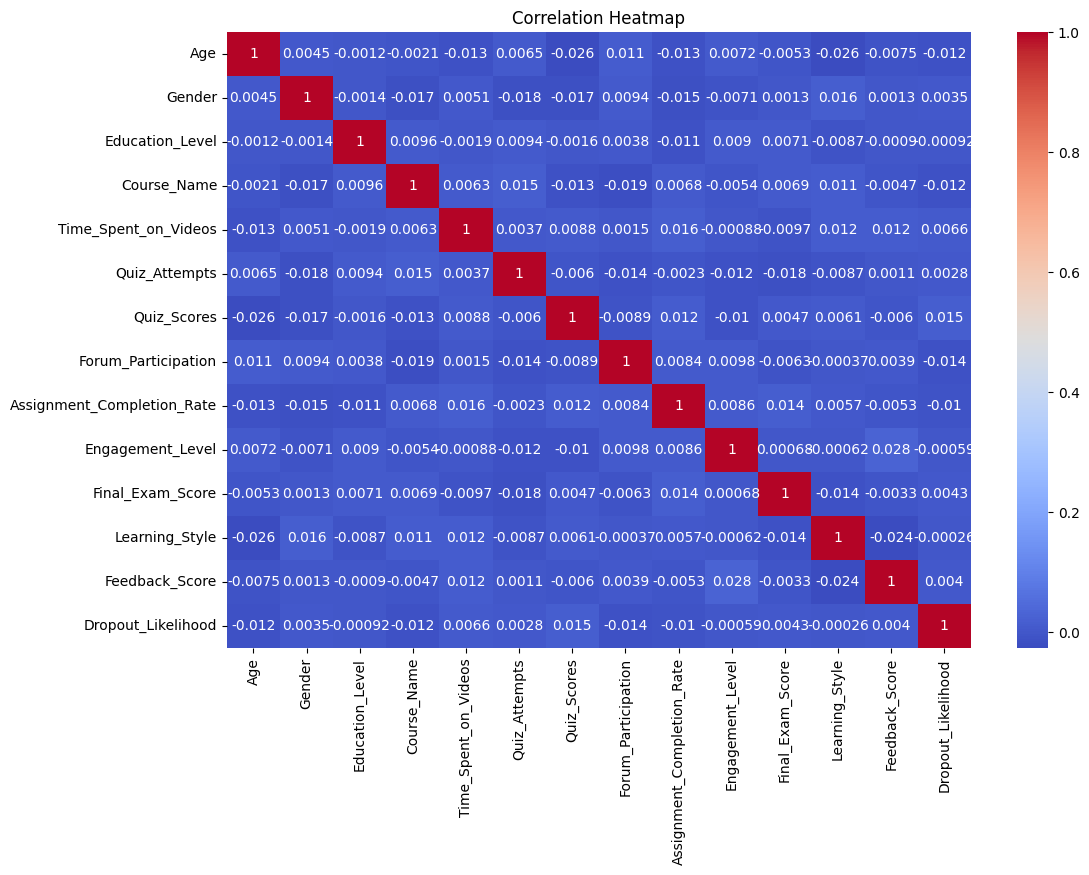

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
X = df[['Age','Gender','Education_Level','Course_Name','Time_Spent_on_Videos','Quiz_Attempts','Quiz_Scores','Forum_Participation','Assignment_Completion_Rate','Engagement_Level','Final_Exam_Score','Feedback_Score']]

In [ ]:
y = df['Dropout_Likelihood']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Model Building

Logistic Regression was used to predict student dropout likelihood.

The dataset was split into training and testing data.

The model was evaluated using:
- Accuracy
- Confusion Matrix
- Classification Report

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8115


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1623    0]
 [ 377    0]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90      1623
           1       0.00      0.00      0.00       377

    accuracy                           0.81      2000
   macro avg       0.41      0.50      0.45      2000
weighted avg       0.66      0.81      0.73      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Results

The model successfully predicted dropout likelihood with good accuracy.

Students with:
- low quiz scores
- low engagement
- poor assignment completion

were more likely to dropout.

# Business Insights

1. Students with low quiz scores are more likely to dropout.

2. Low assignment completion strongly increases dropout risk.

3. Students spending less time on educational videos perform poorly.

4. Higher participation improves student engagement.

5. Educational institutions can identify at-risk students early and provide support.

# Business Recommendations

1. Monitor low-engagement students regularly.

2. Encourage assignment completion through reminders.

3. Provide academic support for students with low quiz scores.

4. Increase student participation in discussions and activities.

5. Use predictive systems to identify at-risk students early.

# Conclusion

This project successfully developed a Student Dropout Prediction System using Logistic Regression and end-to-end machine learning solution for student droput likelihood

The project included:
- Data cleaning
- Feature engineering
- Data visualization
- Machine learning model training
- Model evaluation
- Business insights

The system can help educational institutions reduce dropout rates through early intervention and improve retention startegies